In [1]:
# ============================================================
# Cell 0 - Import Packages and Load BTMS Model
# ============================================================

import os
import sys
import io
import re
import contextlib
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import CoolProp.CoolProp as CP

PROJECT_ROOT = os.path.abspath("../..")

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import lib.BTMS_model as BTMS_model

# Always reload the latest BTMS_model.py
BTMS_model = importlib.reload(BTMS_model)

print(f'Project root: {PROJECT_ROOT}')
print(f'BTMS_model loaded from: {BTMS_model.__file__}')


Project root: d:\Workspace\eBATS
BTMS_model loaded from: d:\Workspace\eBATS\lib\BTMS_model.py


In [2]:
# result-file naming configuration
# [RESULTID]_[SCN]_[BTMS]_[MODEL]_[TASK].[ext]
# This notebook runs one selected liquid-cooling validation condition using the 1D model.

CASE_ID = 'C0009'
REVISION = 'R00'
RESULT_ID = f'{CASE_ID}{REVISION}'

SCENARIO_CODE = 'PARK25'
BTMS_CODE = 'LC'
MODEL_CODE = '1D'
TASK_CODE = 'EVAL'

RESULT_BASENAME = f'{RESULT_ID}_{SCENARIO_CODE}_{BTMS_CODE}_{MODEL_CODE}_{TASK_CODE}'
NOTEBOOK_NAME = f'{RESULT_BASENAME}.ipynb'
OUTPUT_DIR = os.path.join(
    PROJECT_ROOT,
    'out',
    CASE_ID
)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Only store the file name here, not the full path.
RESULT_FIGURE_NAME = f'{RESULT_BASENAME}.png'


# ---------------------------------------------------------
# CFD validation-data directory
# PROJECT_ROOT/data/...
# ---------------------------------------------------------
CFD_DATA_DIR = os.path.join(
    PROJECT_ROOT,
    'data',
    'C0015',
    'C0015R01_PARK25_LC_THERM_CFD_EVAL'
)


In [3]:
# read the single-cell heat-generation profile Qbat(W)

# Keep the physical simulation duration unchanged, while using the original time step.
SIM_DURATION_S = 1920.0   # s, physical mission duration
dt = 1.0                 # s, integration time step

NUM_STEPS = int(round(SIM_DURATION_S / dt))
if not np.isclose(NUM_STEPS * dt, SIM_DURATION_S):
    raise ValueError('SIM_DURATION_S must be an integer multiple of dt.')

# Keep the original variable name for downstream compatibility.
# Here SIM_TIME_S means the number of numerical time steps, not the physical duration.
SIM_TIME_S = NUM_STEPS

file_name = os.path.join(
    PROJECT_ROOT,
    'data',
    'MD05E070207A1  data_power gen_single cell_Liu_20260421.xlsx'
)

if not os.path.isfile(file_name):
    raise FileNotFoundError(
        f'Heat-generation data file not found: {file_name}\n'
        'Place the Excel file in the data folder beside this notebook.'
    )

df = pd.read_excel(file_name, sheet_name='Sheet1')
power_generation_data_1s = df['Qbat(W)'].dropna().to_numpy(dtype=float)

# The source Qbat data are treated as 1-s samples. For dt = 1.0 s,
# each 1-s heat-generation value is used for one numerical time step.
time_s = np.arange(SIM_TIME_S + 1) * dt
power_indices = np.floor(time_s[:-1]).astype(int)
power_indices = np.clip(power_indices, 0, len(power_generation_data_1s) - 1)
power_generation_data = power_generation_data_1s[power_indices]

print(f'Simulation duration: {SIM_DURATION_S:.1f} s')
print(f'Time step dt: {dt:.3f} s')
print(f'Number of numerical steps: {SIM_TIME_S}')
print(f'Q_gen array length: {len(power_generation_data)}')

Simulation duration: 1920.0 s
Time step dt: 1.000 s
Number of numerical steps: 1920
Q_gen array length: 1920


In [4]:

# ============================================================
# Cell 3 - Model Settings and Selected Liquid-Cooling Design
# ============================================================

# ------------------------------------------------------------
# Battery cell properties
# ------------------------------------------------------------
BATTERY_PROPS = {
    'm_bat': 48e-3,          # kg
    'cp_bat': 830.0,         # J/(kg K)
    'D_bat': 18e-3,          # m
    'H_bat': 65e-3,          # m
}


# ------------------------------------------------------------
# 1D module layout
# ------------------------------------------------------------
MODULE_LAYOUT = {
    'N_r': 20,               # cells/control volumes along coolant-flow direction
    'N_c': 16,               # battery columns in transverse direction
}


# ------------------------------------------------------------
# Liquid-cooling system settings
# ------------------------------------------------------------
LIQUID_SETTINGS = {
    'fluid': 'Water',
    'p_water': 101325.0,     # Pa

    # Selected rectangular-channel geometry
    'W_channel': 8.0e-3,     # m, 8 mm
    'H_channel': 3.0e-3,     # m, 3 mm
    'L_channel': 0.380,      # m, 380 mm
    'S_channel': 17.77e-3,   # m, clear spacing between channels

    # Cold-plate geometry
    'delta_plate_coolant': 2.0e-3,   # m

    # Aluminium cold-plate properties
    'k_plate': 200.0,        # W/(m K)
    'rho_plate': 2719.0,     # kg/m3

    # Pump and additional components
    'pump_efficiency': 0.35,
    'K_minor': 0.0,
    'm_pump': 0.0,           # kg
    'm_pipe': 0.0,           # kg
}


# ------------------------------------------------------------
# Cooling period
# ------------------------------------------------------------
# Liquid cooling is active during the full mission.
COOLING_PERIOD = {
    't_cruise_start': 180.0,
    't_cruise_end': 1560.0,
}


# ------------------------------------------------------------
# Solver settings
# ------------------------------------------------------------
SOLVER_SETTINGS = {
    'solver_tol': 1e-6,
    'solver_maxiter': 1000,
}


# ------------------------------------------------------------
# Mission-stage definitions
# ------------------------------------------------------------
mission_stages = [
    ('takeoff',       0.0,    6.0),
    ('climb',         6.0,   36.0),
    ('transition1',  36.0,  180.0),
    ('cruise',      180.0, 1560.0),
    ('transition2',1560.0, 1704.0),
    ('descent',    1704.0, 1734.0),
    ('hover',      1734.0, 1914.0),
    ('landing',    1914.0, 1920.0),
]


# ------------------------------------------------------------
# Selected liquid-cooling condition
# ------------------------------------------------------------
SELECTED_CONDITION = {
    'case_id': f'{CASE_ID}_S001',

    # Operating condition
    'T_water': 20.0,                  # degC
    'm_dot_total': 0.060,             # kg/s, total system coolant flow
    'num_parallel_channels': 20,

    # Selected rectangular-channel geometry
    'W_channel': LIQUID_SETTINGS['W_channel'],
    'H_channel': LIQUID_SETTINGS['H_channel'],
    'L_channel': LIQUID_SETTINGS['L_channel'],
}


# ============================================================
# Map configuration values to downstream variables
# ============================================================

# Battery
m_bat = BATTERY_PROPS['m_bat']
cp_bat = BATTERY_PROPS['cp_bat']
D_bat = BATTERY_PROPS['D_bat']
H_bat = BATTERY_PROPS['H_bat']

A_battery = np.pi * D_bat * H_bat


# Module
N_r = MODULE_LAYOUT['N_r']
N_c = MODULE_LAYOUT['N_c']
num_seg = N_r


# Liquid cooling
fluid = LIQUID_SETTINGS['fluid']
p_water = LIQUID_SETTINGS['p_water']

W_channel = LIQUID_SETTINGS['W_channel']
H_channel = LIQUID_SETTINGS['H_channel']
L_channel = LIQUID_SETTINGS['L_channel']
S_channel = LIQUID_SETTINGS['S_channel']

delta_plate_coolant = LIQUID_SETTINGS['delta_plate_coolant']

k_plate = LIQUID_SETTINGS['k_plate']
rho_plate = LIQUID_SETTINGS['rho_plate']

pump_efficiency = LIQUID_SETTINGS['pump_efficiency']
K_minor = LIQUID_SETTINGS['K_minor']
m_pump = LIQUID_SETTINGS['m_pump']
m_pipe = LIQUID_SETTINGS['m_pipe']


# Total cold-plate thickness
H_plate = H_channel + delta_plate_coolant


# Mission-stage times retained for downstream indicators
t_cruise_start = COOLING_PERIOD['t_cruise_start']
t_cruise_end = COOLING_PERIOD['t_cruise_end']


# Cooling operates during the full mission
pump_operation_time = SIM_DURATION_S


# Solver
solver_tol = SOLVER_SETTINGS['solver_tol']
solver_maxiter = SOLVER_SETTINGS['solver_maxiter']


# ------------------------------------------------------------
# Equivalent number of cells represented by one cooling channel
# ------------------------------------------------------------
SELECTED_CONDITION['num_cell_seg'] = (
    N_c / SELECTED_CONDITION['num_parallel_channels']
)


# ------------------------------------------------------------
# Derived hydraulic diameter
# NOTE:
# Dh is a derived quantity, NOT an independent design parameter.
# ------------------------------------------------------------
Dh_selected = (2.0* W_channel* H_channel/ (W_channel + H_channel))


# ------------------------------------------------------------
# Print selected condition
# ------------------------------------------------------------
print('Selected liquid-cooling condition:')
print(f"  T_water = {SELECTED_CONDITION['T_water']:.1f} degC")
print(f"  m_dot_total = {SELECTED_CONDITION['m_dot_total']:.3f} kg/s")
print(f"  N_ch = {SELECTED_CONDITION['num_parallel_channels']}")
print(f"  num_cell_seg = {SELECTED_CONDITION['num_cell_seg']:.3f}")

print()
print('Selected rectangular-channel geometry:')
print(f'  W_channel = {W_channel * 1e3:.2f} mm')
print(f'  H_channel = {H_channel * 1e3:.2f} mm')
print(f'  L_channel = {L_channel * 1e3:.2f} mm')
print(f'  S_channel = {S_channel * 1e3:.2f} mm')
print(f'  Dh (derived) = {Dh_selected * 1e3:.3f} mm')
print(f'  delta_plate_coolant = {delta_plate_coolant * 1e3:.2f} mm')
print(f'  H_plate = {H_plate * 1e3:.2f} mm')



Selected liquid-cooling condition:
  T_water = 20.0 degC
  m_dot_total = 0.060 kg/s
  N_ch = 20
  num_cell_seg = 0.800

Selected rectangular-channel geometry:
  W_channel = 8.00 mm
  H_channel = 3.00 mm
  L_channel = 380.00 mm
  S_channel = 17.77 mm
  Dh (derived) = 4.364 mm
  delta_plate_coolant = 2.00 mm
  H_plate = 5.00 mm


In [5]:
# ============================================================
# Cell 4 - Build the Selected Single Case
# ============================================================

single_case = {
    'case_id': SELECTED_CONDITION['case_id'],
    'T_water': float(SELECTED_CONDITION['T_water']),
    'm_dot_total': float(SELECTED_CONDITION['m_dot_total']),
    'num_parallel_channels': int(SELECTED_CONDITION['num_parallel_channels']),
    'num_cell_seg': float(SELECTED_CONDITION['num_cell_seg']),
    'W_channel': float(SELECTED_CONDITION['W_channel']),
    'H_channel': float(SELECTED_CONDITION['H_channel']),
    'L_channel': float(SELECTED_CONDITION['L_channel']),
}

print('Selected single case:')
print(single_case)


Selected single case:
{'case_id': 'C0009_S001', 'T_water': 20.0, 'm_dot_total': 0.06, 'num_parallel_channels': 20, 'num_cell_seg': 0.8, 'W_channel': 0.008, 'H_channel': 0.003, 'L_channel': 0.38}


In [6]:
# calculate water properties at the selected inlet temperature

T_water = float(single_case['T_water'])
T_water_K = T_water + 273.15

mu_water = CP.PropsSI('V', 'T', T_water_K, 'P', p_water, fluid)
rho_water = CP.PropsSI('D', 'T', T_water_K, 'P', p_water, fluid)
cp_water = CP.PropsSI('C', 'T', T_water_K, 'P', p_water, fluid)
k_water = CP.PropsSI('L', 'T', T_water_K, 'P', p_water, fluid)
Pr_water = cp_water * mu_water / k_water

water_props_cache = {
    T_water: {
        'mu_water': mu_water,
        'rho_water': rho_water,
        'cp_water': cp_water,
        'k_water': k_water,
        'Pr_water': Pr_water,
    }
}

print(f'Water properties calculated at T_water = {T_water:.1f} degC.')


Water properties calculated at T_water = 20.0 degC.


In [7]:
# ============================================================
# Cell 6 - Run the Selected Single Case
# ============================================================

def run_one_case(case_id, T_water, m_dot_total, num_parallel_channels, num_cell_seg, W_channel, H_channel, L_channel):

    water_props = water_props_cache[float(T_water)]

    # Flow and channel geometry
    m_dot_channel = m_dot_total / num_parallel_channels
    A_cool_cs = W_channel * H_channel
    Dh = 2.0 * W_channel * H_channel / (W_channel + H_channel)
    A_HT_seg = (W_channel + 2.0 * H_channel) * L_channel / num_seg
    W_plate = num_parallel_channels * W_channel + (num_parallel_channels + 1) * S_channel

    u_water = m_dot_channel / (water_props['rho_water'] * A_cool_cs)
    Re_water = water_props['rho_water'] * u_water * Dh / water_props['mu_water']

    # Heat transfer
    Nu_water = BTMS_model.liquid_nusselt_number_rect_channel(W_channel, H_channel)
    h_water = Nu_water * water_props['k_water'] / Dh
    R_plate = delta_plate_coolant / k_plate
    htc_global = 1.0 / (1.0 / h_water + R_plate)
    htc_cool = np.ones(num_seg) * htc_global

    # Pump power
    f_water = BTMS_model.cal_friction_factor_rect_channel(Re_water, W_channel, H_channel)

    pump_args = {
        'fluid_cool': fluid,
        'rho_cool': water_props['rho_water'],
        'mu_cool': water_props['mu_water'],
        'A_cool_cs': A_cool_cs,
        'D_channel': Dh,
        'L_channel': L_channel,
        'm_dot_total': m_dot_total,
        'num_channel': num_parallel_channels,
        'pump_efficiency': pump_efficiency,
        'K_minor': K_minor,
        'operation_time': pump_operation_time,
    }

    pump_results = BTMS_model.cal_btms_aux_power(pump_args, friction_factor=f_water)
    P_pump = float(pump_results['P_aux_W'])
    E_pump_cumulative = float(pump_results['E_aux_J'])

    # BTMS mass
    mass_args = {
        'fluid_cool': fluid,
        'rho_cool': water_props['rho_water'],
        'rho_plate': rho_plate,
        'L_channel': L_channel,
        'W_plate': W_plate,
        'A_cool_cs': A_cool_cs,
        'H_channel': H_channel,
        'H_bottom': delta_plate_coolant,
        'num_channel': num_parallel_channels,
        'm_pump': m_pump,
        'm_pipe': m_pipe,
        'return_components': True,
    }

    mass_results = BTMS_model.cal_btms_mass(mass_args)
    mtotal = float(mass_results['m_BTMS_kg'])

    # Initial temperatures
    T_bat = np.ones(num_seg) * T_water
    T_cool = np.ones(num_seg) * T_water

    T_bat_history = np.zeros((SIM_TIME_S + 1, num_seg))
    T_water_history = np.zeros((SIM_TIME_S + 1, num_seg))
    T_bat_history[0, :] = T_bat
    T_water_history[0, :] = T_cool

    # Time marching
    for k in range(SIM_TIME_S):

        args = {
            'num_seg': num_seg,
            'num_seg_bat': num_seg,
            'dt': dt,
            'T_cool_pre': T_cool,
            'T_bat_pre': T_bat,
            'u_cool_in': u_water,
            'p_cool': p_water,
            'fluid_cool': fluid,
            'A_HT_seg': A_HT_seg,
            'A_cool_cs': A_cool_cs,
            'm_bat': m_bat,
            'cp_bat': cp_bat,
            'D_bat': D_bat,
            'T_cool_in': T_water,
            'T_cool_out': max(float(T_cool[-1]), T_water),
            'is_cool': True,
            'htc_cool': htc_cool,
            'cp_cool': water_props['cp_water'],
            'rho_cool': water_props['rho_water'],
            'Q_gen': power_generation_data[k],
            'num_cell_seg': num_cell_seg,
            'debug': False,
        }

        with contextlib.redirect_stdout(io.StringIO()):
            T_dist = BTMS_model.solve_coolant_temperature_distribution(args, tol=solver_tol, maxiter=solver_maxiter, debug=False)

        T_cool = T_dist[:num_seg]
        T_bat = T_dist[num_seg:]

        T_bat_history[k + 1, :] = T_bat
        T_water_history[k + 1, :] = T_cool

    # Results
    Tmax = np.max(T_bat_history, axis=1)
    Tmin = np.min(T_bat_history, axis=1)
    DeltaT = Tmax - Tmin
    Twater_out = T_water_history[:, -1]

    def idx(t):
        return int(round(t / dt))

    row = {
        'case_id': case_id,
        'T_water_in_C': float(T_water),
        'm_dot_total_kg_s': float(m_dot_total),
        'm_dot_channel_kg_s': float(m_dot_channel),
        'num_parallel_channels': int(num_parallel_channels),
        'num_cell_seg': float(num_cell_seg),
        'W_channel_mm': float(W_channel * 1e3),
        'H_channel_mm': float(H_channel * 1e3),
        'L_channel_mm': float(L_channel * 1e3),
        'Dh_mm': float(Dh * 1e3),
        'u_water_m_s': float(u_water),
        'Re_water': float(Re_water),
        'Nu_water': float(Nu_water),
        'h_water_W_m2K': float(h_water),
        'htc_global_W_m2K': float(htc_global),
        'P_pump': P_pump,
        'E_pump_cumulative': E_pump_cumulative,
        'm_plate_kg': float(mass_results['m_plate_kg']),
        'm_coolant_kg': float(mass_results['m_coolant_kg']),
        'mtotal': mtotal,
        'Tmax_mission_C': float(np.max(Tmax)),
        'DeltaT_mission_max_C': float(np.max(DeltaT)),
        'cruise_recovery_Tmax_C': float(Tmax[idx(t_cruise_start)] - Tmax[idx(t_cruise_end)]),
        'Twater_out_cruise_end_C': float(Twater_out[idx(t_cruise_end)]),
    }

    for stage_name, t0, t1 in mission_stages:
        row[f'dTmax_{stage_name}_C'] = float(Tmax[idx(t1)] - Tmax[idx(t0)])

    histories = {
        'time_s': time_s.copy(),
        'Tmax_C': Tmax.copy(),
        'Tmin_C': Tmin.copy(),
        'DeltaT_C': DeltaT.copy(),
        'Twater_out_C': Twater_out.copy(),
        'T_bat_history_C': T_bat_history.copy(),
        'T_water_history_C': T_water_history.copy(),
    }

    return row, histories

Running selected single condition...


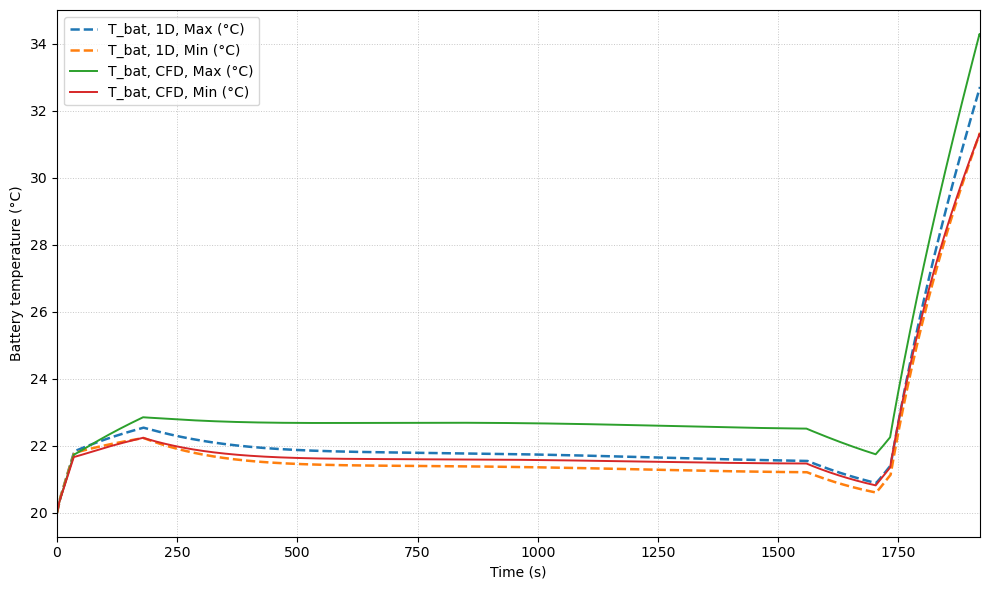


Selected-condition results:
  Tmax = 32.714 °C
  DeltaTmax = 1.365 °C
  P_pump,total = 0.0143 W
  E_pump = 27.45 J
  m_total = 2.441 kg

Saved figure: d:\Workspace\eBATS\out\C0009\C0009R00_PARK25_LC_1D_EVAL.png


In [8]:
# ============================================================
# Cell 7 - Run Selected Case and Compare with CFD
# ============================================================

print('Running selected single condition...')
summary_row, histories = run_one_case(**single_case)


# ------------------------------------------------------------
# Read CFD results
# ------------------------------------------------------------
CFD_FILES = {
    'CFD_avg_max': 'bat_avg_max.out',
    'CFD_avg_min': 'bat_avg_min.out',
}

def read_fluent_temperature_history(file_path):
    rows = []

    with open(file_path, 'r', encoding='utf-8', errors='ignore') as file:
        for line in file:
            tokens = re.sub(r'[(),]', ' ', line.strip()).split()

            try:
                values = [float(token) for token in tokens]
            except ValueError:
                continue

            if len(values) >= 3:
                rows.append([values[-1], values[-2]])
            elif len(values) == 2:
                rows.append([values[0], values[1]])

    data = np.asarray(rows, dtype=float)
    time_cfd = data[:, 0]
    temperature_cfd = data[:, 1]

    if np.nanmedian(temperature_cfd) > 150.0:
        temperature_cfd -= 273.15

    return time_cfd, temperature_cfd


cfd_histories = {}

for line_name, file_name in CFD_FILES.items():
    file_path = os.path.join(CFD_DATA_DIR, file_name)
    cfd_histories[line_name] = read_fluent_temperature_history(file_path)


# ------------------------------------------------------------
# Plot 1D and CFD temperature histories
# ------------------------------------------------------------
plt.rcdefaults()
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(histories['time_s'], histories['Tmax_C'], linewidth=1.8, linestyle='--', label='T_bat, 1D, Max (°C)')
ax.plot(histories['time_s'], histories['Tmin_C'], linewidth=1.8, linestyle='--', label='T_bat, 1D, Min (°C)')

time_cfd, temperature_cfd = cfd_histories['CFD_avg_max']
ax.plot(time_cfd, temperature_cfd, linewidth=1.4, label='T_bat, CFD, Max (°C)')

time_cfd, temperature_cfd = cfd_histories['CFD_avg_min']
ax.plot(time_cfd, temperature_cfd, linewidth=1.4, label='T_bat, CFD, Min (°C)')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Battery temperature (°C)')
ax.set_xlim(0.0, SIM_DURATION_S)
ax.grid(True, linestyle=':', linewidth=0.7, alpha=0.7)
ax.legend()

fig.tight_layout()

figure_path = os.path.join(OUTPUT_DIR, RESULT_FIGURE_NAME)
fig.savefig(figure_path, dpi=600, bbox_inches='tight')
plt.show()


# ------------------------------------------------------------
# Print selected-case results
# ------------------------------------------------------------
print()
print('Selected-condition results:')
print(f"  Tmax = {summary_row['Tmax_mission_C']:.3f} °C")
print(f"  DeltaTmax = {summary_row['DeltaT_mission_max_C']:.3f} °C")
print(f"  P_pump,total = {summary_row['P_pump']:.4f} W")
print(f"  E_pump = {summary_row['E_pump_cumulative']:.2f} J")
print(f"  m_total = {summary_row['mtotal']:.3f} kg")
print()
print(f'Saved figure: {figure_path}')